In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from collections import Counter
import json
import os
import math


In [ ]:
experiment_uuid = "21b3782a-4c2e-4fee-b745-80b310113b91"

full_experiment_df = pd.read_csv(f"combined_{experiment_uuid}.csv")

In [ ]:
full_experiment_df = full_experiment_df.drop_duplicates()

In [ ]:
full_experiment_df

,run_uuid,round,epoch,epochs_per_round,accuracy,mean_accuracy,ub_accuracy,lb_accuracy,std_accuracy,var_accuracy,...,message_length,mean_message_length,ub_message_length,lb_message_length,std_message_length,var_message_length,var_bern_message_length,control_group,params,timestamp
0,0f0b62c0-1d93-4a2c-890e-9dfb5d472a20,0,1,10,[1. 0. 1. ... 1. 1. 1.],0.831750,1.564963,0.098537,0.374088,0.139942,...,[4. 4. 4. ... 4. 4. 4.],4.000000,4.000000,4.000000,0.000000,0.000000,32000.0,False,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 12:15:05.536629
1,0f0b62c0-1d93-4a2c-890e-9dfb5d472a20,0,2,10,[0. 1. 1. ... 1. 1. 1.],0.912750,1.465864,0.359636,0.282201,0.079637,...,[4. 4. 4. ... 4. 4. 4.],4.000000,4.000000,4.000000,0.000000,0.000000,32000.0,False,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 12:16:08.089471
2,0f0b62c0-1d93-4a2c-890e-9dfb5d472a20,0,3,10,[1. 1. 0. ... 1. 1. 1.],0.934625,1.419110,0.450140,0.247186,0.061101,...,[4. 4. 4. ... 4. 4. 4.],4.000000,4.000000,4.000000,0.000000,0.000000,32000.0,False,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 12:17:13.037466
3,0f0b62c0-1d93-4a2c-890e-9dfb5d472a20,0,4,10,[1. 1. 1. ... 1. 1. 1.],0.945750,1.389710,0.501790,0.226510,0.051307,...,[4. 4. 4. ... 4. 4. 4.],4.000000,4.000000,4.000000,0.000000,0.000000,32000.0,False,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 12:18:16.094891
4,0f0b62c0-1d93-4a2c-890e-9dfb5d472a20,0,5,10,[1. 1. 1. ... 1. 1. 1.],0.949125,1.379820,0.518430,0.219742,0.048287,...,[4. 4. 4. ... 4. 4. 4.],4.000000,4.000000,4.000000,0.000000,0.000000,32000.0,False,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 12:19:18.700289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6295,fe99ef81-4a5d-4b69-b21f-e1db8bc70c07,9,86,10,[1. 1. 1. ... 1. 1. 1.],0.867375,1.532146,0.202604,0.339169,0.115036,...,[4. 2. 4. ... 4. 4. 3.],3.360000,5.185696,1.534304,0.931477,0.867650,26880.0,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 15:28:41.956622
6296,fe99ef81-4a5d-4b69-b21f-e1db8bc70c07,9,87,10,[1. 0. 1. ... 1. 1. 1.],0.781500,1.591428,-0.028428,0.413228,0.170758,...,[2. 2. 4. ... 4. 4. 2.],3.177625,5.106084,1.249165,0.983908,0.968075,25421.0,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 15:29:42.617438
6297,fe99ef81-4a5d-4b69-b21f-e1db8bc70c07,9,88,10,[0. 1. 1. ... 1. 0. 1.],0.790875,1.587975,-0.006225,0.406684,0.165392,...,[2. 4. 4. ... 4. 2. 4.],3.200625,5.120400,1.280850,0.979477,0.959375,25605.0,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 15:30:45.473430
6298,fe99ef81-4a5d-4b69-b21f-e1db8bc70c07,9,89,10,[1. 0. 1. ... 1. 1. 1.],0.903500,1.482240,0.324760,0.295276,0.087188,...,[4. 4. 4. ... 4. 4. 4.],3.538500,5.188883,1.888118,0.842032,0.709018,28308.0,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-01-28 15:31:46.636350


In [ ]:
print(f"{len(full_experiment_df['run_uuid'].unique())} runs")

30 runs


In [ ]:
full_experiment_df["full_epoch"] = np.where(
            full_experiment_df["control_group"] == False,
            full_experiment_df["round"] * full_experiment_df["epochs_per_round"] + full_experiment_df["epoch"].astype(int),
            full_experiment_df["epoch"] + np.where(full_experiment_df["round"] >= 1, 10, 0)
        )

max_full_epoch = full_experiment_df['full_epoch'].max()


def check_completion(series, max_full_epoch):
    run_uuid = series.name
    run_data = full_experiment_df[full_experiment_df['run_uuid'] == run_uuid]
    max_round = run_data['round'].max()
    n_epochs = run_data['epochs_per_round'].iloc[0]

    print(f"Run: {run_uuid}")
    print(f"max_round: {max_round}")
    print(f"n_epochs: {n_epochs}")
    print(f"max_full_epoch: {max_full_epoch}")
    print(f"expected: {(max_round + 1) * n_epochs}")

    result = max_full_epoch == (max_round + 1) * n_epochs
    print(f"completed: {result}\n")
    return result

df = full_experiment_df.copy()
df['completed'] = df.groupby('run_uuid')['full_epoch'].transform(lambda x: check_completion(x, max_full_epoch))

Run: 06b30fd0-352f-4e91-8648-b39087d29f1c
max_round: 9
n_epochs: 10
max_full_epoch: 100
expected: 100
completed: True

Run: 0f0b62c0-1d93-4a2c-890e-9dfb5d472a20
max_round: 9
n_epochs: 10
max_full_epoch: 100
expected: 100
completed: True

Run: 11ed5084-0ef5-4ba2-acb2-d5c89134d1ad
max_round: 9
n_epochs: 10
max_full_epoch: 100
expected: 100
completed: True

Run: 23e6b6ac-9a0a-42ab-b2b8-6182609fa02f
max_round: 9
n_epochs: 10
max_full_epoch: 100
expected: 100
completed: True

Run: 32ce7532-4504-415a-adda-1eb1f3ea8fbe
max_round: 9
n_epochs: 10
max_full_epoch: 100
expected: 100
completed: True

Run: 3999346c-4a5f-489a-a993-9869f60b75ac
max_round: 9
n_epochs: 10
max_full_epoch: 100
expected: 100
completed: True

Run: 4073fe1f-4c60-4593-a2bb-ee2eb8647006
max_round: 9
n_epochs: 10
max_full_epoch: 100
expected: 100
completed: True

Run: 48ad0338-2d47-4bb7-82f9-d98a7c8eff0a
max_round: 9
n_epochs: 10
max_full_epoch: 100
expected: 100
completed: True

Run: 4a63d696-d19c-459e-93a9-62598e46b873
max_ro

In [ ]:
df = df.loc[df["completed"] == True]


In [ ]:
df = df.drop_duplicates()

In [ ]:


def validate_and_deduplicate_runs(df: pd.DataFrame) -> pd.DataFrame:
    cleaned_df = df.copy()

    groups = 2
    most_common_epochs = stats.mode(df["epochs_per_round"], keepdims=False).mode
    expected_rows = groups * most_common_epochs * len(df["round"].unique())

    row_counts = df['run_uuid'].map(Counter(df['run_uuid']))
    invalid_runs = df.loc[row_counts != expected_rows, "run_uuid"].unique()

    if len(invalid_runs) == 0:
        return cleaned_df

    print(f"Found {len(invalid_runs)} runs with incorrect row count (expected {expected_rows}):")
    print(invalid_runs)

    problem_df = df[df['run_uuid'].isin(invalid_runs)].copy()
    epoch_counts = problem_df['full_epoch'].map(Counter(problem_df['full_epoch']))
    duplicate_df = problem_df.loc[epoch_counts != groups].copy()

    if duplicate_df.empty:
        return cleaned_df

    duplicate_df['timestamp'] = pd.to_datetime(duplicate_df['timestamp'])

    control_dupes = len(duplicate_df.loc[duplicate_df["control_group"]]) > 1
    experiment_dupes = len(duplicate_df.loc[~duplicate_df["control_group"]]) > 1

    if control_dupes:
        print("Found duplicates in control group")
        reference_time = duplicate_df.loc[~duplicate_df["control_group"], "timestamp"].iloc[0]
        duplicate_df.loc[duplicate_df["control_group"], "time_diff"] = (
            duplicate_df.loc[duplicate_df["control_group"], "timestamp"] - reference_time
        ).abs()

    elif experiment_dupes:
        print("Found duplicates in experiment group")
        reference_time = duplicate_df.loc[duplicate_df["control_group"], "timestamp"].iloc[0]
        duplicate_df.loc[~duplicate_df["control_group"], "time_diff"] = (
            duplicate_df.loc[~duplicate_df["control_group"], "timestamp"] - reference_time
        ).abs()

    if control_dupes or experiment_dupes:
        duplicate_df = duplicate_df.sort_values('time_diff')
        rows_to_keep = duplicate_df.drop_duplicates(
            subset=['run_uuid', 'round', 'epoch', 'full_epoch'],
            keep='first'
        ).index
        rows_to_remove = duplicate_df.index.difference(rows_to_keep)

        cleaned_df = cleaned_df.drop(rows_to_remove)

    return cleaned_df


df = validate_and_deduplicate_runs(df)


In [ ]:
groups = 2
rows_req = groups * stats.mode(df["epochs_per_round"]).mode * len(df["round"].unique())

run_uuid = df[df['run_uuid'].map(Counter(df['run_uuid'])) != rows_req]["run_uuid"].unique()

incorrect_epochs = [73]
df.loc[df['run_uuid'].isin(run_uuid)][df.loc[df['run_uuid'].isin(run_uuid)]["full_epoch"].isin(incorrect_epochs)]

,run_uuid,round,epoch,epochs_per_round,accuracy,mean_accuracy,ub_accuracy,lb_accuracy,std_accuracy,var_accuracy,...,ub_message_length,lb_message_length,std_message_length,var_message_length,var_bern_message_length,control_group,params,timestamp,full_epoch,completed


In [ ]:

def perform_wilcoxen(df, metrics=['mean_accuracy', 'var_accuracy', 'topographic_similarity', 'positional_disentanglement']):
    results = {}

    for metric in metrics:
        control = df.loc[df['control_group'] == True, metric]
        experimental = df.loc[df['control_group'] == False, metric]

        t_stat, p_val = stats.ttest_ind(control, experimental)

        stat, p_value = stats.wilcoxon(experimental, control)


        results[metric] = {
            'statistic': stat,
            'p_value': p_val,
            'control_mean': control.mean(),
            'experimental_mean': experimental.mean(),
            'control_std': control.std(),
            'experimental_std': experimental.std()
        }

    return results


print(json.dumps(perform_wilcoxen(df)))

{"mean_accuracy": {"statistic": 930286.5, "p_value": 3.3471467355617636e-06, "control_mean": 0.9337039583333333, "experimental_mean": 0.9387541250000001, "control_std": 0.0417823364583637, "experimental_std": 0.04229359447249483}, "var_accuracy": {"statistic": 929411.0, "p_value": 1.8245719939507832e-09, "control_mean": 0.06015569457833334, "experimental_mean": 0.055706665765999995, "control_std": 0.028343766891936805, "experimental_std": 0.02888036775540141}, "topographic_similarity": {"statistic": 1464617.0, "p_value": 5.875492563996803e-10, "control_mean": 0.1748808295062681, "experimental_mean": 0.18565825185139684, "control_std": 0.06647943264231328, "experimental_std": 0.06807390193132615}, "positional_disentanglement": {"statistic": NaN, "p_value": NaN, "control_mean": NaN, "experimental_mean": NaN, "control_std": NaN, "experimental_std": NaN}}


In [ ]:

def perform_variance_comparison(df, metrics=['mean_accuracy', 'var_accuracy', 'positional_disentanglement']):
    results = {}

    for metric in metrics:
        control = df[df['control_group'] == True][metric]
        experimental = df[df['control_group'] == False][metric]

        f_stat = np.var(control) / np.var(experimental)
        dfn = len(control) - 1
        dfd = len(experimental) - 1
        p_val = 2 * min(stats.f.cdf(f_stat, dfn, dfd),
                       1 - stats.f.cdf(f_stat, dfn, dfd))

        levene_stat, levene_p = stats.levene(control, experimental)

        results[metric] = {
            'f_statistic': f_stat,
            'f_test_p_value': p_val,
            'levene_statistic': levene_stat,
            'levene_p_value': levene_p,
            'control_variance': np.var(control),
            'experimental_variance': np.var(experimental),
            'variance_ratio': f_stat
        }

    return results


In [ ]:

def create_plots(df, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    plt.style.use("seaborn-v0_8")

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='full_epoch', y='mean_accuracy', hue='control_group', errorbar=('ci', 95))
    plt.title('Learning Curves: Mean Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Accuracy')
    plt.savefig(output_dir / 'learning_curves.png')
    plt.close()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    sns.lineplot(data=df, x='full_epoch', y='message_entropy',
                hue='control_group', errorbar=('ci', 95), ax=ax1)
    ax1.set_title('Message Entropy over Epochs')

    sns.lineplot(data=df, x='full_epoch', y='vocab_usage',
                hue='control_group', errorbar=('ci', 95), ax=ax2)
    ax2.set_title('Vocabulary Usage over Epochs')

    plt.tight_layout()
    plt.savefig(output_dir / 'message_evolution.png')
    plt.close()

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 6), sharey=True)
    fig.suptitle("Accuracy Distributions", fontsize=24)
    sns.violinplot(data=df, x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax1)
    ax1.set_xticklabels(["experimental", "control"])
    ax1.set_title('Including common round 0 ').set_fontsize(20)
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Group')

    sns.violinplot(data=df.loc[df["round"] > 0], x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax2)
    ax2.set_xticklabels(["experimental", "control"])
    ax2.set_title('Excluding common round 0 ').set_fontsize(20)
    ax2.set_ylabel('Accuracy')
    ax2.set_xlabel('Group')

    sns.violinplot(data=df.loc[df["round"] > 5], x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax3)
    ax3.set_xticklabels(["experimental", "control"])
    ax3.set_title('After 5 rounds').set_fontsize(20)
    ax3.set_ylabel('Accuracy')
    ax3.set_xlabel('Group')

    sns.violinplot(data=df.loc[df["round"] > 8], x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax4)
    ax4.set_xticklabels(["experimental", "control"])
    ax4.set_title('Final round').set_fontsize(20)
    ax4.set_ylabel('Accuracy')
    ax4.set_xlabel('Group')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'accuracy_dist.png')
    plt.close()


    metrics = ['mean_accuracy', 'topographic_similarity',
               'positional_disentanglement']
    correlation = df[metrics].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Key Metrics')
    plt.tight_layout()
    plt.savefig(output_dir / 'correlation_matrix.png')
    plt.close()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    sns.violinplot(data=df, x='control_group', y='var_accuracy', ax=ax1)
    ax1.set_xticklabels(["experimental", "control"])
    ax1.set_title('Distribution of Variance in Accuracy including base round')
    ax1.set_ylabel('Variance')
    ax1.set_xlabel('Group')

    sns.violinplot(data=df.loc[df["round"] > 0], x='control_group', y='var_accuracy', ax=ax2)
    ax2.set_xticklabels(["experimental", "control"])
    ax2.set_title('Distribution of Variance in Accuracy excluding base round')
    ax2.set_ylabel('Variance')
    ax2.set_xlabel('Group')

    plt.tight_layout()
    plt.savefig(output_dir / 'variance_comparison.png')
    plt.close()

    plt.figure(figsize=(12, 6))
    for group in [True, False]:
        group_data = df[df['control_group'] == group]
        plt.fill_between(group_data['full_epoch'],
                        group_data['lb_accuracy'],
                        group_data['ub_accuracy'],
                        alpha=0.2)
        plt.plot(group_data['full_epoch'], group_data['mean_accuracy'],
                label=f'{"Control" if group else "Experimental"} Group')

    plt.title('Accuracy Evolution with Confidence Bands')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(output_dir / 'accuracy_evolution.png')
    plt.close()


In [ ]:
from scipy import stats
# for some reason this additional import is required

input_path = ""
output_dir = ""

test_results = perform_wilcoxen(df)
with open(os.path.join(output_dir, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=4)

variance_results = perform_variance_comparison(df)
with open(os.path.join(output_dir, 'variance_comparison_results.json'), 'w') as f:
    json.dump(variance_results, f, indent=4)

create_plots(df, output_dir)

print("\nT-Test Results Summary:")
for metric, stats in test_results.items():
    print(f"\n{metric}:")
    print(f"statistic: {stats['statistic']:.4f}")
    print(f"p-value: {stats['p_value']:.4f}")
    print(f"Control group: mean={stats['control_mean']:.4f}, std={stats['control_std']:.4f}")
    print(f"Experimental group: mean={stats['experimental_mean']:.4f}, std={stats['experimental_std']:.4f}")

print("\nVariance Comparison Results:")
for metric, stats in variance_results.items():
    print(f"\n{metric}:")
    print(f"F-statistic: {stats['f_statistic']:.4f}")
    print(f"F-test p-value: {stats['f_test_p_value']:.4f}")
    print(f"Levene's test statistic: {stats['levene_statistic']:.4f}")
    print(f"Levene's test p-value: {stats['levene_p_value']:.4f}")
    print(f"Control group variance: {stats['control_variance']:.4f}")
    print(f"Experimental group variance: {stats['experimental_variance']:.4f}")
    print(f"Variance ratio (control/experimental): {stats['variance_ratio']:.4f}")

<ipython-input-56-7cf846e75ba6>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax1)
<ipython-input-56-7cf846e75ba6>:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(["experimental", "control"])
<ipython-input-56-7cf846e75ba6>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df.loc[df["round"] > 0], x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax2)
<ipython-input-56-7cf846e75ba6>:52: UserWarning: set_ticklabels() should only be u


T-Test Results Summary:

mean_accuracy:
statistic: 930286.5000
p-value: 0.0000
Control group: mean=0.9337, std=0.0418
Experimental group: mean=0.9388, std=0.0423

var_accuracy:
statistic: 929411.0000
p-value: 0.0000
Control group: mean=0.0602, std=0.0283
Experimental group: mean=0.0557, std=0.0289

topographic_similarity:
statistic: 1464617.0000
p-value: 0.0000
Control group: mean=0.1749, std=0.0665
Experimental group: mean=0.1857, std=0.0681

positional_disentanglement:
statistic: nan
p-value: nan
Control group: mean=nan, std=nan
Experimental group: mean=nan, std=nan

Variance Comparison Results:

mean_accuracy:
F-statistic: 0.9760
F-test p-value: 0.5054
Levene's test statistic: 0.9074
Levene's test p-value: 0.3409
Control group variance: 0.0017
Experimental group variance: 0.0018
Variance ratio (control/experimental): 0.9760

var_accuracy:
F-statistic: 0.9632
F-test p-value: 0.3044
Levene's test statistic: 1.2261
Levene's test p-value: 0.2682
Control group variance: 0.0008
Experimen

In [ ]:
df_no_base_round = df.loc[df["round"] > 0]

In [ ]:
from scipy import stats
# for some reason this additional import is required

input_path = ""
output_dir = "no_base_round"

os.makedirs(output_dir, exist_ok=True)

test_results = perform_wilcoxen(df_no_base_round)
with open(os.path.join(output_dir, 'test_results_without_base.json'), 'w') as f:
    json.dump(test_results, f, indent=4)

variance_results = perform_variance_comparison(df_no_base_round)
with open(os.path.join(output_dir, 'variance_comparison_results_without_base.json'), 'w') as f:
    json.dump(variance_results, f, indent=4)

create_plots(df_no_base_round, output_dir)

print("\nT-Test Results Summary:")
for metric, stats in test_results.items():
    print(f"\n{metric}:")
    print(f"t-statistic: {stats['statistic']:.4f}")
    print(f"p-value: {stats['p_value']:.4f}")
    print(f"Control group: mean={stats['control_mean']:.4f}, std={stats['control_std']:.4f}")
    print(f"Experimental group: mean={stats['experimental_mean']:.4f}, std={stats['experimental_std']:.4f}")

print("\nVariance Comparison Results:")
for metric, stats in variance_results.items():
    print(f"\n{metric}:")
    print(f"F-statistic: {stats['f_statistic']:.4f}")
    print(f"F-test p-value: {stats['f_test_p_value']:.4f}")
    print(f"Levene's test statistic: {stats['levene_statistic']:.4f}")
    print(f"Levene's test p-value: {stats['levene_p_value']:.4f}")
    print(f"Control group variance: {stats['control_variance']:.4f}")
    print(f"Experimental group variance: {stats['experimental_variance']:.4f}")
    print(f"Variance ratio (control/experimental): {stats['variance_ratio']:.4f}")

<ipython-input-20-242bf386ac9f>:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='control_group', y='mean_accuracy', common_norm=True, palette=["#8aa5d3", "#81bb91"], ax=ax1)
<ipython-input-20-242bf386ac9f>:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(["experimental", "control"])
<ipython-input-20-242bf386ac9f>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df.loc[df["round"] > 0], x='control_group', y='mean_accuracy', common_norm=True, palette=["#8aa5d3", "#81bb91"], ax=ax2)
<ipython-input-20-242bf386ac9f>:51: UserWarning: set_ticklabels() should only be u


T-Test Results Summary:

mean_accuracy:
t-statistic: 930286.5000
p-value: 0.0000
Control group: mean=0.9413, std=0.0197
Experimental group: mean=0.9469, std=0.0187

var_accuracy:
t-statistic: 929411.0000
p-value: 0.0000
Control group: mean=0.0548, std=0.0164
Experimental group: mean=0.0499, std=0.0157

topographic_similarity:
t-statistic: 1464617.0000
p-value: 0.0000
Control group: mean=0.1722, std=0.0663
Experimental group: mean=0.1841, std=0.0685

positional_disentanglement:
t-statistic: nan
p-value: nan
Control group: mean=nan, std=nan
Experimental group: mean=nan, std=nan

Variance Comparison Results:

mean_accuracy:
F-statistic: 1.1180
F-test p-value: 0.0038
Levene's test statistic: 12.6038
Levene's test p-value: 0.0004
Control group variance: 0.0004
Experimental group variance: 0.0003
Variance ratio (control/experimental): 1.1180

var_accuracy:
F-statistic: 1.0848
F-test p-value: 0.0345
Levene's test statistic: 12.3103
Levene's test p-value: 0.0005
Control group variance: 0.0003

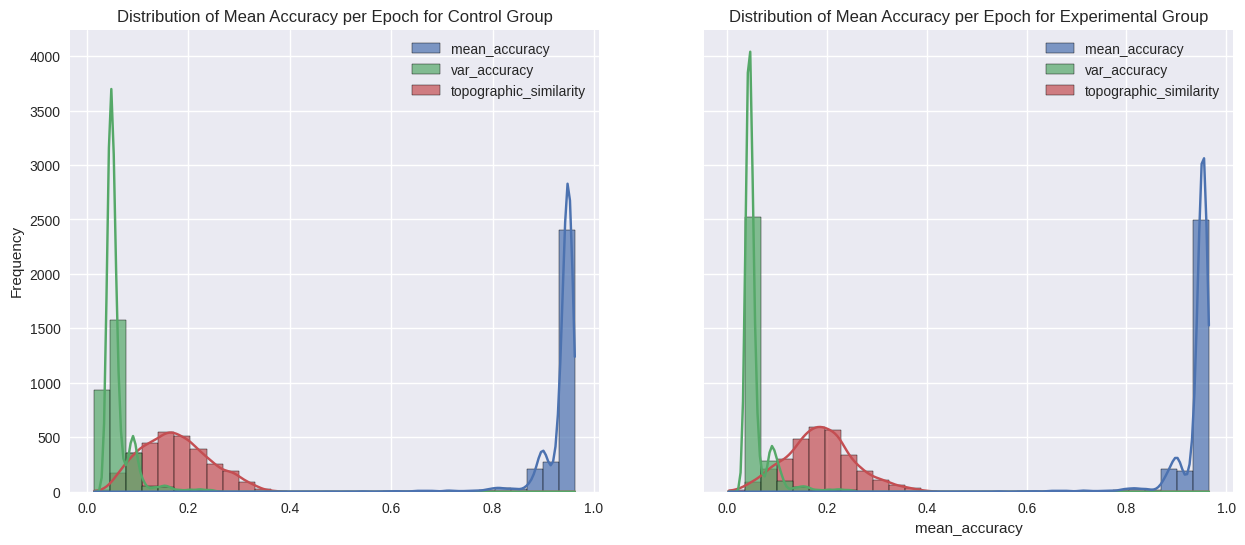

shapiro_stat mean of the accuracy control group: 0.5038
p-value mean of the accuracy control group: 0.0000
shapiro_stat mean of the accuracy experiment group: 0.4724
p-value mean of the accuracy experiment group: 0.0000
shapiro_stat variance of the accuracy control group: 0.6117
p-value variance of the accuracy control group: 0.0000
shapiro_stat variance of the accuracy experiment group: 0.5695
p-value variance of the accuracy experiment group: 0.0000
shapiro_stat topographic similarity control group: 0.9872
p-value topographic similarity control group: 0.0000
shapiro_stat topographic similarity experiment group: 0.9953
p-value topographic similarity experiment group: 0.0000
shapiro_stat positional disentanglement control group: 0.9872
p-value positional disentanglement control group: 0.0000
shapiro_stat positional disentanglement experiment group: 0.9953
p-value positional disentanglement experiment group: 0.0000
\begin{table}[h]
\centering
\begin{tabular}{lccc}
\toprule
Metric & Grou

In [ ]:
from scipy import stats
# for some reason this additional import is required

mean_accuracy = df['mean_accuracy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.histplot(df.loc[df["control_group"] == True][["mean_accuracy", "var_accuracy", "topographic_similarity"]], kde=True, bins=30, alpha=0.7, ax=ax1)
ax1.set_title('Distribution of Mean Accuracy per Epoch for Control Group')
ax1.set_ylabel('Frequency')

sns.histplot(df.loc[df["control_group"] == False][["mean_accuracy", "var_accuracy", "topographic_similarity"]], kde=True, bins=30, alpha=0.7, ax=ax2)
ax2.set_title('Distribution of Mean Accuracy per Epoch for Experimental Group')
ax2.set_ylabel('Frequency')

plt.xlabel('mean_accuracy')

plt.grid(True)

plt.show()


shapiro_stat_mean_control, shapiro_p_value_mean_control = stats.shapiro(df.loc[df["control_group"] == True]["mean_accuracy"])
print(f"shapiro_stat mean of the accuracy control group: {shapiro_stat_mean_control:.4f}")
print(f"p-value mean of the accuracy control group: {shapiro_p_value_mean_control:.4f}")

shapiro_stat_mean, shapiro_p_value_mean = stats.shapiro(df.loc[df["control_group"] == False]["mean_accuracy"])
print(f"shapiro_stat mean of the accuracy experiment group: {shapiro_stat_mean:.4f}")
print(f"p-value mean of the accuracy experiment group: {shapiro_p_value_mean:.4f}")

shapiro_stat_variance_control, shapiro_p_value_variance_control = stats.shapiro(df.loc[df["control_group"] == True]["var_accuracy"])
print(f"shapiro_stat variance of the accuracy control group: {shapiro_stat_variance_control:.4f}")
print(f"p-value variance of the accuracy control group: {shapiro_p_value_variance_control:.4f}")

shapiro_stat_variance, shapiro_p_value_variance = stats.shapiro(df.loc[df["control_group"] == False]["var_accuracy"])
print(f"shapiro_stat variance of the accuracy experiment group: {shapiro_stat_variance:.4f}")
print(f"p-value variance of the accuracy experiment group: {shapiro_p_value_variance:.4f}")

shapiro_stat_topsim_control, shapiro_p_value_topsim_control = stats.shapiro(df.loc[df["control_group"] == True]["topographic_similarity"])
print(f"shapiro_stat topographic similarity control group: {shapiro_stat_topsim_control:.4f}")
print(f"p-value topographic similarity control group: {shapiro_p_value_topsim_control:.4f}")

shapiro_stat_topsim, shapiro_p_value_topsim = stats.shapiro(df.loc[df["control_group"] == False]["topographic_similarity"])
print(f"shapiro_stat topographic similarity experiment group: {shapiro_stat_topsim:.4f}")
print(f"p-value topographic similarity experiment group: {shapiro_p_value_topsim:.4f}")

shapiro_stat_posdis_control, shapiro_p_value_posdis_control = stats.shapiro(df.loc[df["control_group"] == True]["positional_disentanglement"])
print(f"shapiro_stat positional disentanglement control group: {shapiro_stat_topsim_control:.4f}")
print(f"p-value positional disentanglement control group: {shapiro_p_value_topsim_control:.4f}")

shapiro_stat_posdis, shapiro_p_value_posdis = stats.shapiro(df.loc[df["control_group"] == False]["positional_disentanglement"])
print(f"shapiro_stat positional disentanglement experiment group: {shapiro_stat_topsim:.4f}")
print(f"p-value positional disentanglement experiment group: {shapiro_p_value_topsim:.4f}")



def create_latex_table(results_dict):
    latex_code = [
        "\\begin{table}[h]",
        "\\centering",
        "\\begin{tabular}{lccc}",
        "\\toprule",
        "Metric & Group & Statistic & p-value \\\\",
        "\\midrule"
    ]

    for metric in ["Mean Accuracy", "Variance Accuracy", "Topographic Similarity"]:
        for group in ["Control", "Experiment"]:
            stat_key = f"{metric.lower().replace(' ', '_')}_{group.lower()}_stat"
            p_key = f"{metric.lower().replace(' ', '_')}_{group.lower()}_p"

            row = f"{metric} & {group} & {results_dict[stat_key]:.4f} & {results_dict[p_key]:.4f} \\\\"
            latex_code.append(row)

        if metric != "Positional Disentanglement":
            latex_code.append("\\midrule")

    latex_code.extend([
        "\\bottomrule",
        "\\end{tabular}",
        "\\caption{Shapiro-Wilk Test Results for Normality}",
        "\\label{tab:shapiro_results}",
        "\\end{table}"
    ])

    return "\n".join(latex_code)

results = {
    "mean_accuracy_control_stat": shapiro_stat_mean_control,
    "mean_accuracy_control_p": shapiro_p_value_mean_control,
    "mean_accuracy_experiment_stat": shapiro_stat_mean,
    "mean_accuracy_experiment_p": shapiro_p_value_mean,
    "variance_accuracy_control_stat": shapiro_stat_variance_control,
    "variance_accuracy_control_p": shapiro_p_value_variance_control,
    "variance_accuracy_experiment_stat": shapiro_stat_variance,
    "variance_accuracy_experiment_p": shapiro_p_value_variance,
    "topographic_similarity_control_stat": shapiro_stat_topsim_control,
    "topographic_similarity_control_p": shapiro_p_value_topsim_control,
    "topographic_similarity_experiment_stat": shapiro_stat_topsim,
    "topographic_similarity_experiment_p": shapiro_p_value_topsim
}

print(create_latex_table(results))


In [ ]:
def create_latex_table_wilcoxon(results_dict):
    latex_code = [
        "\\begin{table}[h]",
        "\\centering",
        "\\begin{tabular}{lcccc}",
        "\\toprule",
        "Metric & Control Mean & Experimental Mean & Statistic & p-value \\\\",
        "\\midrule"
    ]

    for metric in results_dict.keys():
        control_mean = results_dict[metric]["control_mean"]
        experimental_mean = results_dict[metric]["experimental_mean"]
        statistic = results_dict[metric]["statistic"]
        p_value = results_dict[metric]["p_value"]
        
        row = f"{metric.replace('_', ' ').title()} & {control_mean:.4f} & {experimental_mean:.4f} & {statistic:.4f} & {p_value:.4f} \\\\"
        latex_code.append(row)

    latex_code.extend([
        "\\bottomrule",
        "\\end{tabular}",
        "\\caption{Wilcoxon Test Results}",
        "\\label{tab:wilcoxon_results}",
        "\\end{table}"
    ])

    return "\n".join(latex_code)



In [ ]:
print(create_latex_table_wilcoxon(perform_wilcoxen(df, ["mean_accuracy", "var_accuracy", "topographic_similarity", "positional_disentanglement"])))


\begin{table}[h]
\centering
\begin{tabular}{lcccc}
\toprule
Metric & Control Mean & Experimental Mean & Statistic & p-value \\
\midrule
Mean Accuracy & 0.9337 & 0.9388 & 930286.5000 & 0.0000 \\
Var Accuracy & 0.0602 & 0.0557 & 929411.0000 & 0.0000 \\
Topographic Similarity & 0.1749 & 0.1857 & 1464617.0000 & 0.0000 \\
Positional Disentanglement & nan & nan & nan & nan \\
\bottomrule
\end{tabular}
\caption{Wilcoxon Test Results}
\label{tab:wilcoxon_results}
\end{table}


In [ ]:
def plot_hypothesis_test(results_dict, metric_label_map=None):
    plot_data = []
    for metric, values in results_dict.items():
        label = metric_label_map[metric] if metric_label_map else metric.replace("_", " ").title()
        plot_data.append({
            "Metric": label,
            "Group": "Control",
            "Mean": values["control_mean"],
            "Std": values["control_std"]
        })
        plot_data.append({
            "Metric": label,
            "Group": "Experimental",
            "Mean": values["experimental_mean"],
            "Std": values["experimental_std"]
        })

    df_plot = pd.DataFrame(plot_data)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df_plot,
        x="Metric",
        y="Mean",
        hue="Group",
        palette="muted",
        ci=None
    )

    for i, (metric, values) in enumerate(results_dict.items()):
        control_mean = values["control_mean"]
        experimental_mean = values["experimental_mean"]
        control_std = values["control_std"]
        experimental_std = values["experimental_std"]
        p_value = values["p_value"]
        stat = values["statistic"]

        ax.errorbar(
            x=i - 0.2,
            y=control_mean,
            yerr=control_std,
            fmt='none',
            capsize=5,
            color='black'
        )
        ax.errorbar(
            x=i + 0.2,
            y=experimental_mean,
            yerr=experimental_std,
            fmt='none',
            capsize=5,
            color='black'
        )

        ax.text(
            x=i, y=max(control_mean, experimental_mean) + 0.02,
            s=f"p={p_value:.3f}, W={stat:.2f}",
            ha="center",
            fontsize=10,
            color="black"
        )

    plt.title("Hypothesis Test Results")
    plt.ylabel("Mean Value")
    plt.xlabel("Metric")
    plt.legend(title="Group")
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_hypothesis_test_context(df, results_dict, metrics, alpha=0.05):
    num_metrics = len(metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6), sharey=True)

    if num_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        control = df.loc[df['control_group'] == True, metric]
        experimental = df.loc[df['control_group'] == False, metric]

        plot_data = pd.concat([
            pd.DataFrame({metric: control, "Group": "Control"}),
            pd.DataFrame({metric: experimental, "Group": "Experimental"})
        ])

        sns.swarmplot(data=plot_data, x="Group", y=metric, ax=ax, color="black", alpha=0.7)

        sns.barplot(
            data=plot_data, x="Group", y=metric, ax=ax,
            ci="sd", capsize=0.2, palette="muted", alpha=0.8
        )

        stat = results_dict[metric]["statistic"]
        p_value = results_dict[metric]["p_value"]
        y_max = max(control.max(), experimental.max())

        ax.text(
            x=0.5, y=y_max + 0.05 * y_max,
            s=f"p={p_value:.3f}, W={stat:.2f}",
            ha="center", fontsize=12, color="red" if p_value < alpha else "blue"
        )

        ax.axhline(y=alpha, color="gray", linestyle="--", linewidth=1, label=f"α={alpha}")

        ax.set_title(f"{metric.replace('_', ' ').title()}", fontsize=14)
        ax.set_ylabel("Value", fontsize=12)
        ax.set_xlabel("Group", fontsize=12)

    plt.suptitle("Hypothesis Test Results in Context of Experiment", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


<ipython-input-31-dcc64581c615>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="Group", y=metric, ax=ax, errorbar="sd", capsize=0.2, palette="muted", alpha=0.8)
<ipython-input-31-dcc64581c615>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="Group", y=metric, ax=ax, errorbar="sd", capsize=0.2, palette="muted", alpha=0.8)
<ipython-input-31-dcc64581c615>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="Group", y=metric, ax=ax, errorbar="sd", capsize=0.2, palette="muted", alpha=0.8)
<

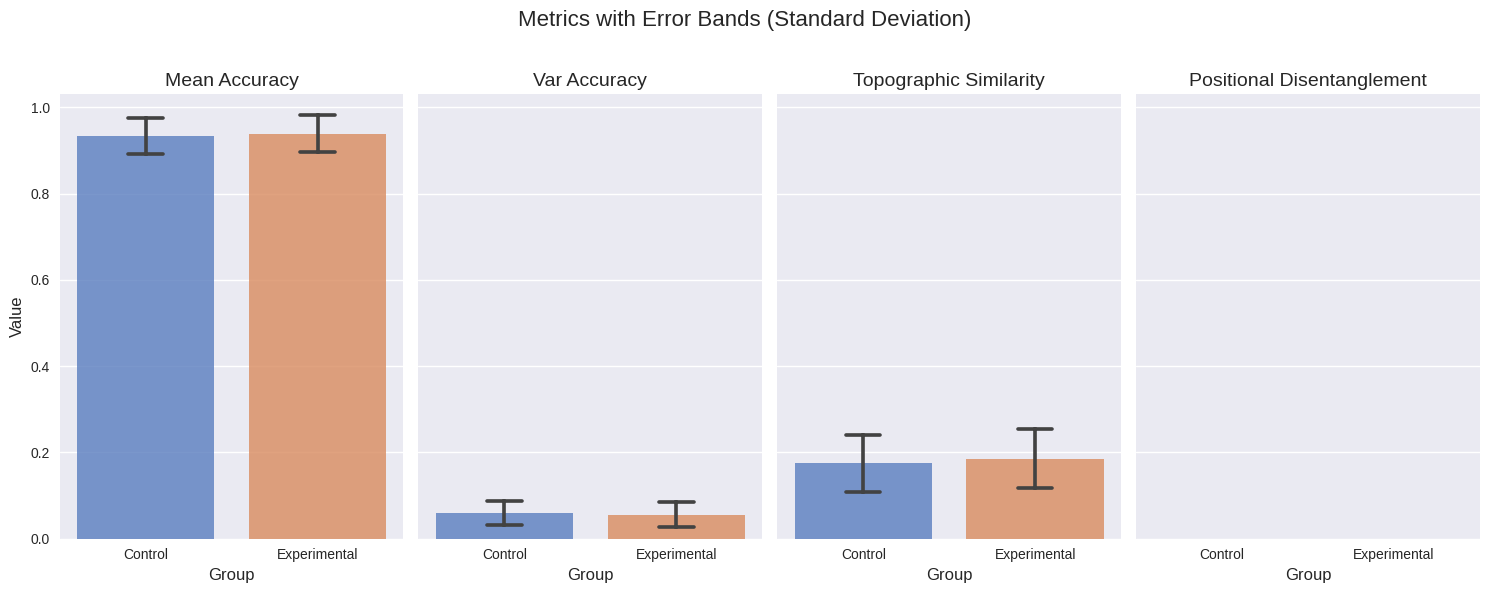

In [ ]:
def plot_metrics_with_error_bands(df, metrics):

    num_metrics = len(metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(15, 6), sharey=True)

    if num_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        plot_data = pd.concat([
            pd.DataFrame({metric: df.loc[df['control_group'] == True, metric], "Group": "Control"}),
            pd.DataFrame({metric: df.loc[df['control_group'] == False, metric], "Group": "Experimental"})
        ])

        sns.barplot(data=plot_data, x="Group", y=metric, ax=ax, errorbar="sd", capsize=0.2, palette="muted", alpha=0.8)

        ax.set_title(f"{metric.replace('_', ' ').title()}", fontsize=14)
        ax.set_ylabel("Value", fontsize=12)
        ax.set_xlabel("Group", fontsize=12)

    plt.suptitle("Metrics with Error Bands (Standard Deviation)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

metrics = ['mean_accuracy', 'var_accuracy', 'topographic_similarity', 'positional_disentanglement']

plot_metrics_with_error_bands(df, metrics)


<ipython-input-58-a0cd7de4ae9d>:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
<ipython-input-58-a0cd7de4ae9d>:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
<ipython-input-58-a0cd7de4ae9d>:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
<ipython-input-58-a0cd7de4ae9d>:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
<ipython-input-58-a0cd7de4ae9d>:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
<ipython-input-58-a0cd7de4ae9d>:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


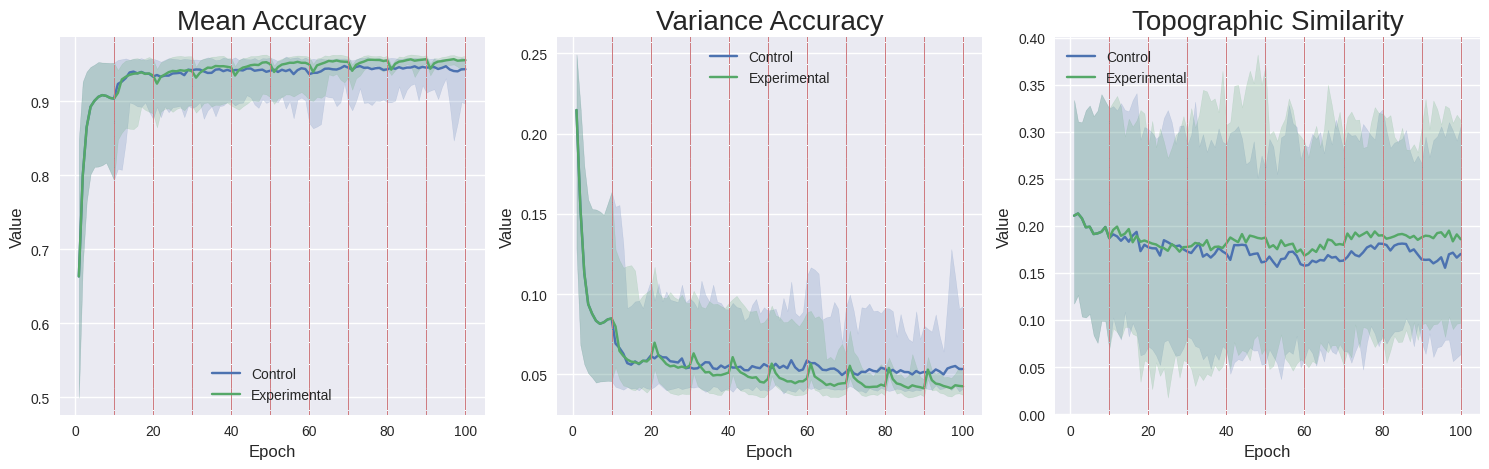

In [ ]:
def plot_metrics_with_error_bands(df, metrics):
    num_metrics = len(metrics)
    plots_per_row = 3
    num_rows = (num_metrics + plots_per_row - 1) // plots_per_row
    num_cols = math.ceil(num_metrics / num_rows)

    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(5*num_cols, 5*num_rows))
    axes = axes.flatten()


    if num_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]

        sns.lineplot(
            data=df[df['control_group'] == True], x='full_epoch', y=metric, ax=ax, label='Control', errorbar=("pi", 95), palette=["#8aa5d3", "#81bb91"]
        )

        sns.lineplot(
            data=df[df['control_group'] == False], x='full_epoch', y=metric, ax=ax, label='Experimental', errorbar=("pi", 95), palette=["#8aa5d3", "#81bb91"]
        )

        for i, row in df.iterrows():
            if row["full_epoch"] % row["epochs_per_round"] == 0:
                ax.axvline(x=row["full_epoch"], linestyle='-.', label=f"round {round}", lw=0.5, color="#cf7c81")

        ax.set_title(f"{metric.replace('_', ' ').replace('var', 'Variance').title()}", fontsize=20)
        ax.set_ylabel("Value", fontsize=12)
        ax.set_xlabel("Epoch", fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

metrics = ['mean_accuracy', 'var_accuracy', 'topographic_similarity']

plot_metrics_with_error_bands(df, metrics)


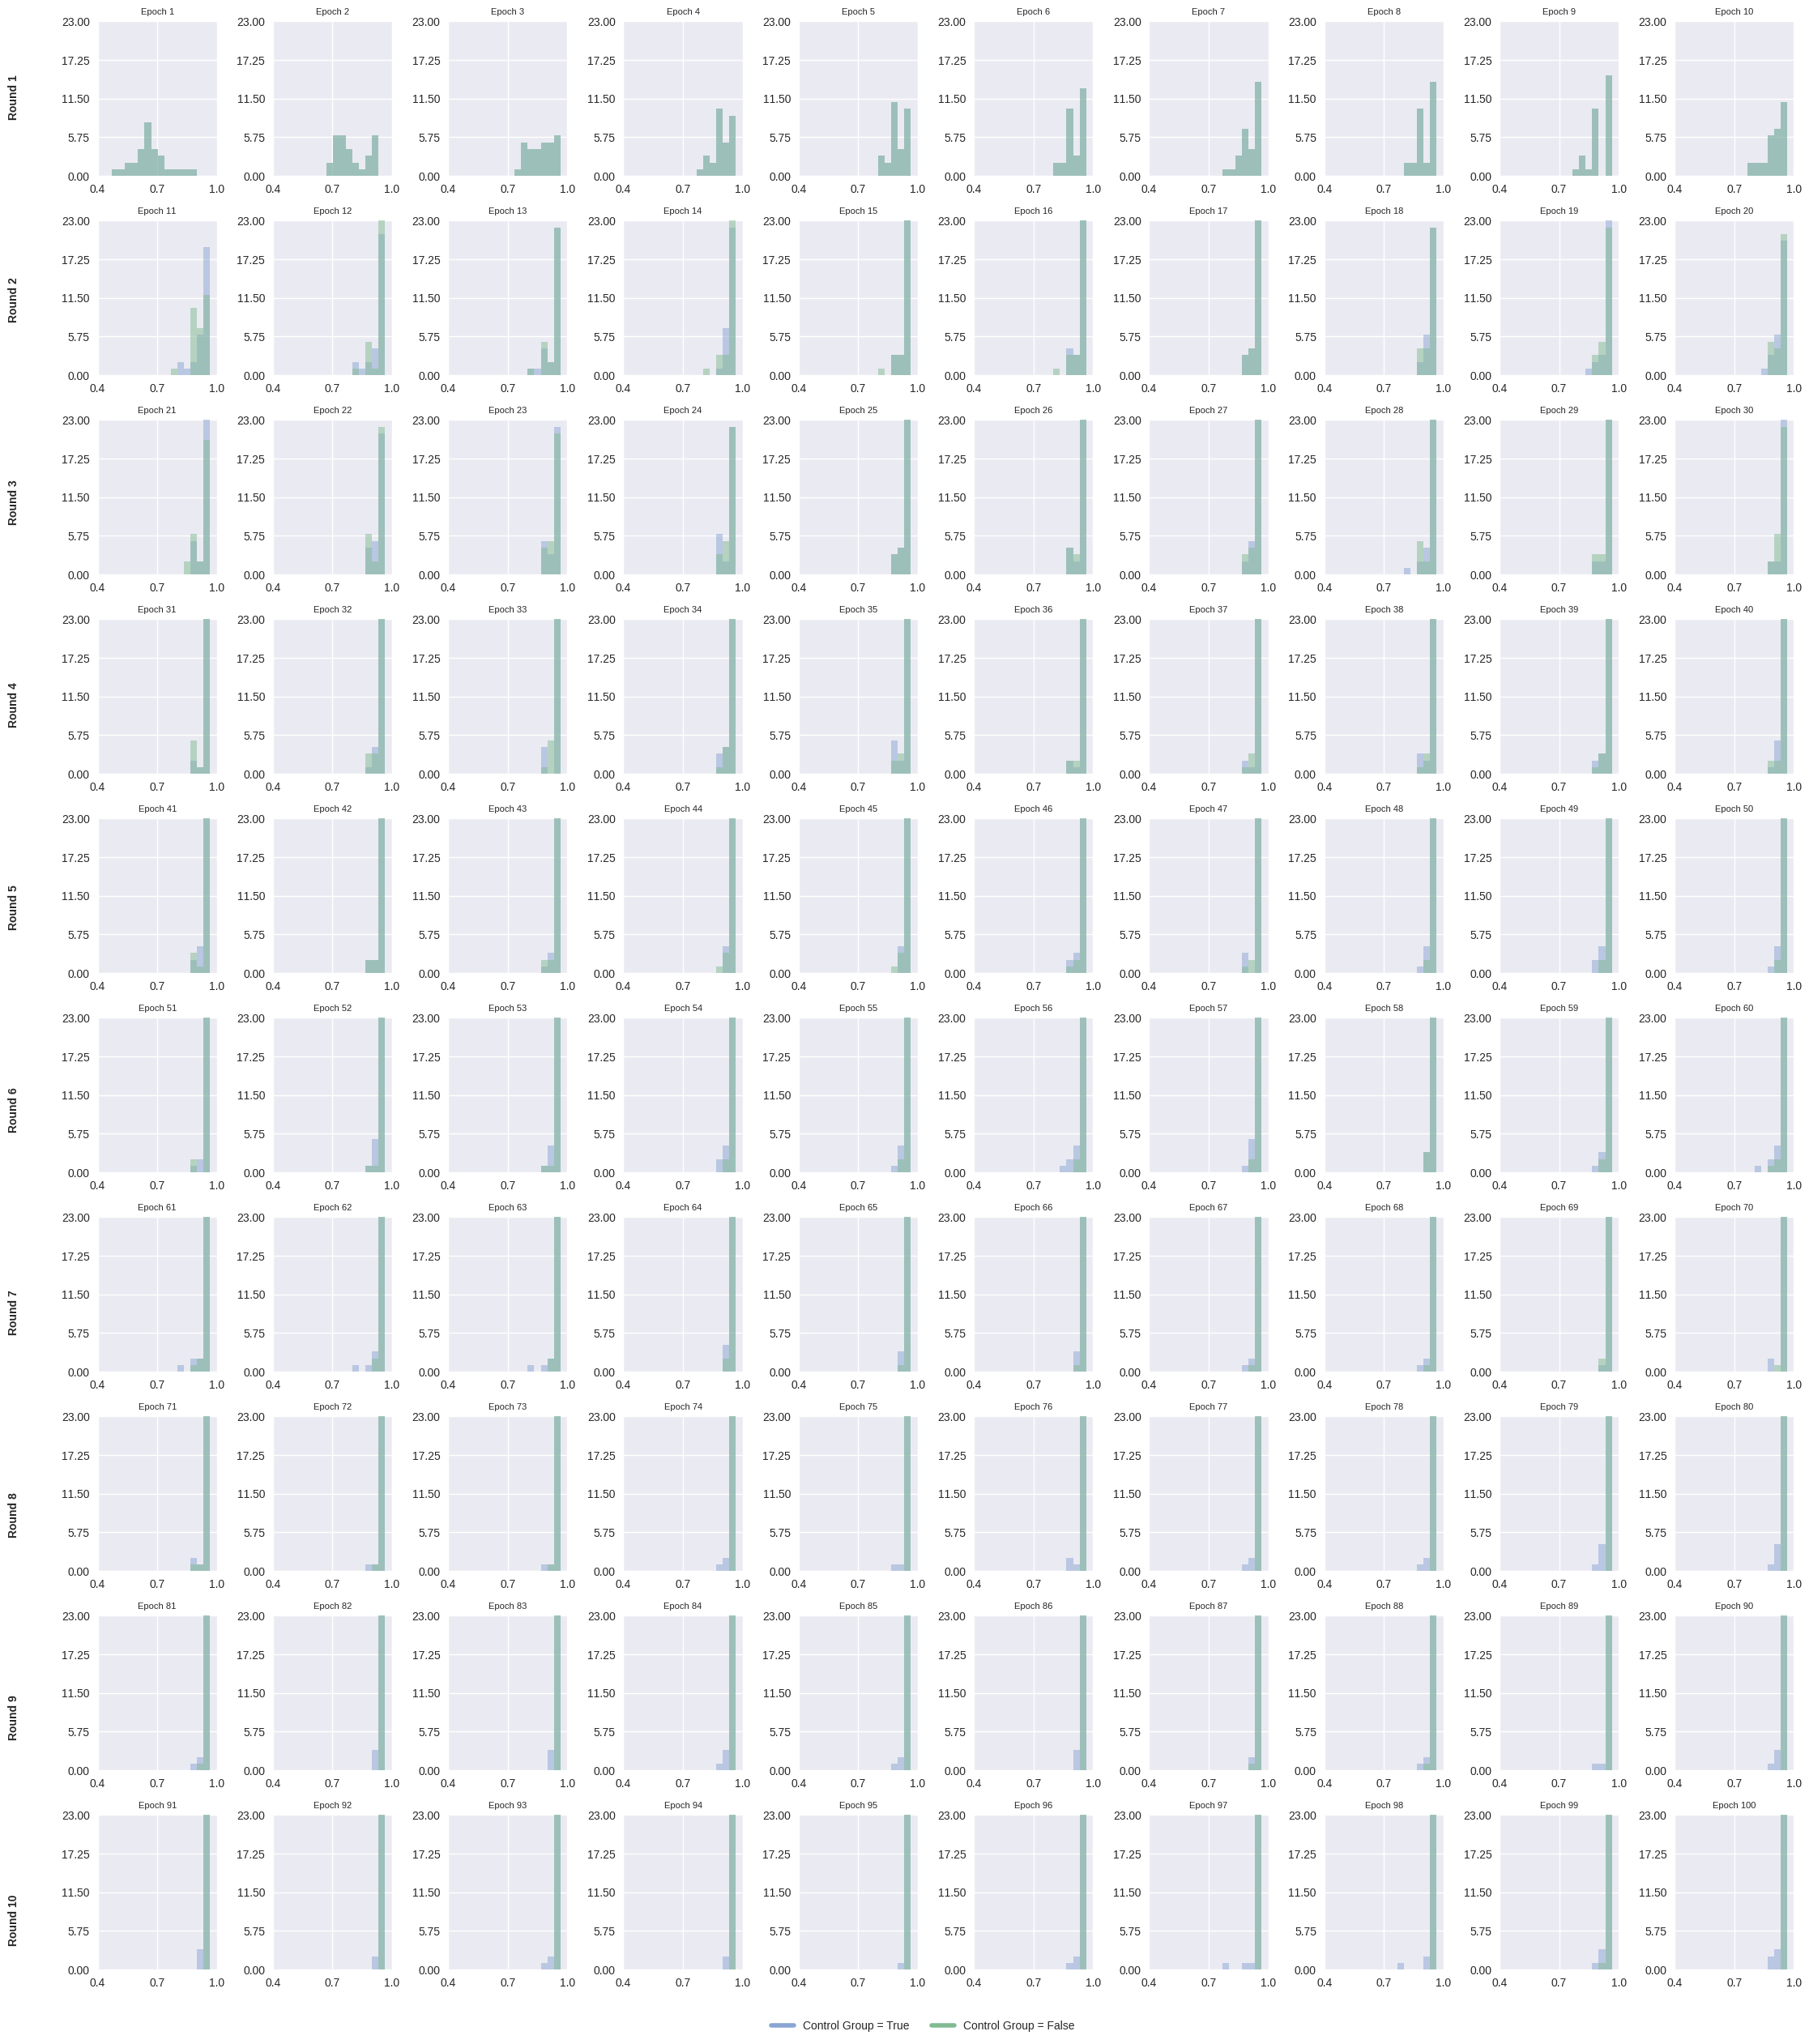

In [ ]:
fig, axes = plt.subplots(10, 10, figsize=(22, 25))

palette = ["#8aa5d3", "#81bb91"]

x_min, x_max = df["mean_accuracy"].min(), df["mean_accuracy"].max()
y_max = 0

for i in range(0, 100):
    for group in [True, False]:
        subset = df[(df["control_group"] == group) & (df["full_epoch"] == i + 1)]
        if not subset.empty:
            counts, _ = np.histogram(subset["mean_accuracy"], bins="auto", range=(x_min, x_max))
            y_max = max(y_max, counts.max())

for i in range(0, 100):
    row, col = divmod(i, 10)
    ax = axes[row, col]

    for group, color in zip([True, False], palette):
        subset = df[(df["control_group"] == group) & (df["full_epoch"] == i + 1)]

        ax.hist(subset["mean_accuracy"], bins=15, alpha=0.5, color=color, label=f'Group {group}', range=(x_min, x_max))

    ax.set_title(f'Epoch {i+1}', fontsize=8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max)
    ax.set_xticks(np.linspace(math.floor(x_min * 10) / 10, math.ceil(x_max * 10) / 10, 3))
    ax.set_yticks(np.linspace(0, math.ceil((y_max + 1) * 10) / 10, 5))

for row in range(10):
    fig.text(
        -0.01,
        1 - (row + 0.5) / 10,
        f"Round {row + 1}",
        ha="center",
        va="center",
        rotation="vertical",
        fontsize=10,
        fontweight="bold"
    )

handles = [
    plt.Line2D([0], [0], color=palette[0], lw=4, label='Control Group = True'),
    plt.Line2D([0], [0], color=palette[1], lw=4, label='Control Group = False')
]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0.01, 0.01, 1, 1])

plt.show()


In [ ]:
def csv_to_latex_table(csv_file, output_file=None, caption=None, label=None, index=False, columns=None, exclude_columns=None):
    df = pd.read_csv(csv_file)

    if columns:
        df = df[columns]

    if exclude_columns:
        df = df.drop(columns=exclude_columns)

    latex_table = df.to_latex(index=index, escape=False)

    if caption or label:
        lines = latex_table.splitlines()
        if caption:
            lines.insert(1, f"\\caption{{{caption}}}")
        if label:
            lines.insert(2 if caption else 1, f"\\label{{{label}}}")
        latex_table = "\n".join(lines)

    if output_file:
        with open(output_file, 'w') as f:
            f.write(latex_table)
    else:
        return latex_table
